In [1]:
import os, sys, copy, pickle
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

sys.path.append('/global/cfs/projectdirs/deepsrch/lensed_sne_search/ucla_proj/carousel_kinematics/iful/src')

from IFUL.image_set import *
from IFUL.util import *

In [2]:
datacube_filename = "/global/cfs/projectdirs/deepsrch/lensed_sne_search/ucla_proj/carousel_kinematics/datacubes/full_datacube.fits"
ifu_psf_filename = "/global/cfs/projectdirs/deepsrch/lensed_sne_search/ucla_proj/carousel_kinematics/datacubes/psfi.pickle"

full_datacube = fits.getdata(datacube_filename, 1)
full_var_datacube = fits.getdata(datacube_filename, 2)

header = fits.getheader(datacube_filename, 1)
full_var_datacube = np.transpose(full_var_datacube, (1, 2, 0)) # np.moveaxis(full_datacube, [0], [2])
full_datacube = np.transpose(full_datacube, (1, 2, 0)) # np.moveaxis(full_datacube, [0], [2])
full_datacube.shape

pixscale = (header['CD1_2']**2 + header['CD1_1']**2)**0.5
wavelengths = (header["CRVAL3"] + header["CD3_3"] * (1 + np.arange(header["NAXIS3"]))) 
delta_wave = wavelengths[1] - wavelengths[0]

zl = 0.49
exptime = fits.getheader(datacube_filename, 0)['EXPTIME']
size = 200

x_bounds = (211-size//2, 211+size//2)
y_bounds = (201-size//2, 201+size//2)

full_datacube = full_datacube[x_bounds[0]:x_bounds[1], y_bounds[0]:y_bounds[1], :]
full_var_datacube = full_var_datacube[x_bounds[0]:x_bounds[1], y_bounds[0]:y_bounds[1], :]

# full_datacube = np.rot90(full_datacube, 3)
# full_var_datacube = np.rot90(full_var_datacube, 3)

/tmp/ipykernel_1468758/1250407982.py:5: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(np.rot90(full_datacube_whitelight.T, 3)))


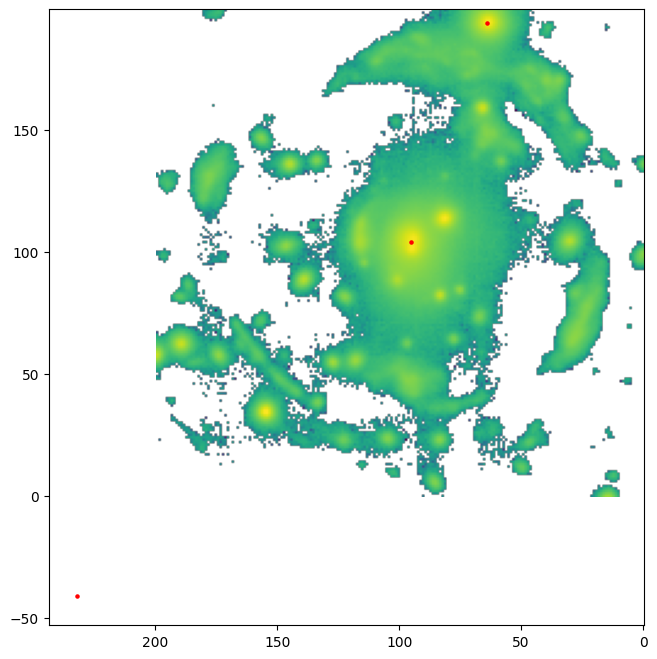

In [3]:
init_lens_center = np.array([(104, 104), (194, 135), (194-235, 135-168)])

plt.figure(figsize=(8, 8))
full_datacube_whitelight = np.nanmedian(full_datacube, axis=2)
plt.imshow(np.log10(np.rot90(full_datacube_whitelight.T, 3)))
# plt.imshow(np.log10((full_datacube_whitelight.T)))

init_lens_center_plt = np.array([[-(j - (size/2-0.5)) + (size/2-0.5), (i - (size/2-0.5)) + (size/2-0.5)] for i, j in init_lens_center])#[0]
plt.scatter(init_lens_center_plt.T[0], init_lens_center_plt.T[1], c='r', s=5)

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.show()

In [4]:
header_wcs = copy.deepcopy(header)
header_wcs['CRPIX1'] = init_lens_center[0, 0] + 1
header_wcs['CRVAL1'] = 0.
header_wcs["NAXIS1"] = full_datacube_whitelight.shape[0]

header_wcs['CRPIX2'] = init_lens_center[0, 1] + 1
header_wcs['CRVAL2'] = 0.
header_wcs["NAXIS2"] = full_datacube_whitelight.shape[1]

with open(ifu_psf_filename, 'rb') as handle:
    psf_info = pickle.load(handle)

general_aux_info = {
    'init_lens_center': init_lens_center,
    'exptime': exptime,
    'zl': zl, 
    'header_wcs': header_wcs,
    'psf_info': psf_info,
    'pixscale': pixscale
}

## Define image set 4

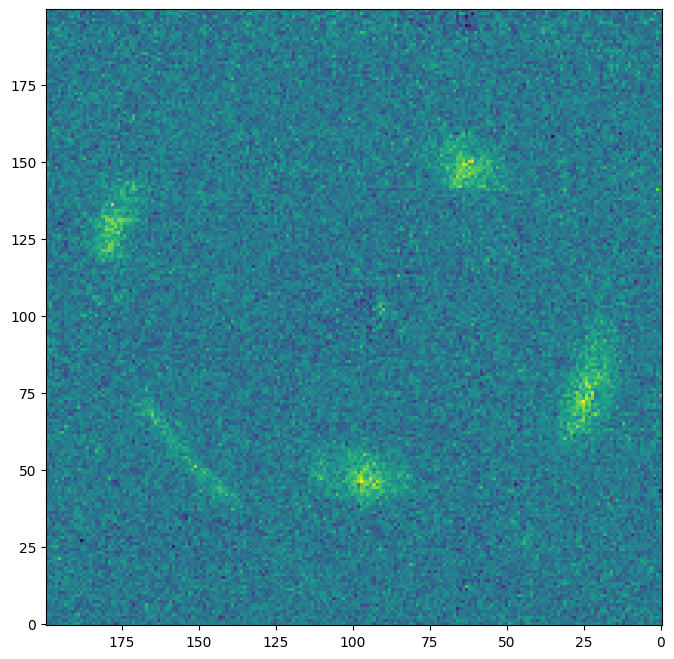

In [5]:
zs = 1.432

spectra_center = 9068
specta_range = 24
gap = 0
spectra_background = 10

# spectra_center = 9068
# specta_range = 24
# gap = 100
# spectra_background = 5

buffer = gap + spectra_background
trunc_inds_buff = np.array([i for i, w in enumerate(wavelengths) if w>=spectra_center-(specta_range//2+buffer)*delta_wave and w<=spectra_center+(specta_range//2+buffer)*delta_wave])
trunc_wave_buff = wavelengths[trunc_inds_buff]
z_bounds_buffer = (np.min(trunc_inds_buff), np.max(trunc_inds_buff)+1)

crop_datacube = full_datacube[:, :, z_bounds_buffer[0]:z_bounds_buffer[1]]
crop_var_datacube = full_var_datacube[:, :, z_bounds_buffer[0]:z_bounds_buffer[1]]

imset4 = ImageSet(crop_datacube, crop_var_datacube, trunc_wave_buff, zs, pixscale, gap, spectra_background)
imset4.add_aux_info(general_aux_info)
imset4.mask_outliers()

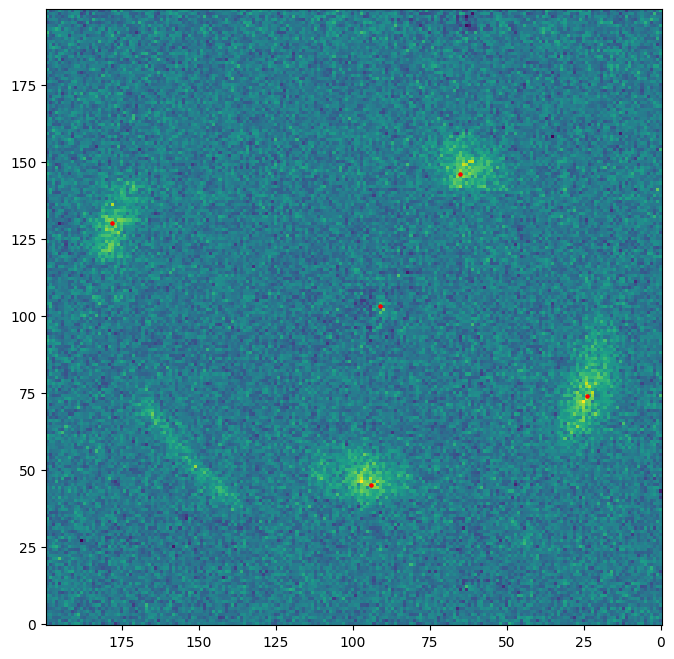

In [6]:
image_locs = np.array([[130, 21], [45, 105], [74, 175], [146, 134], [103, 108]]) # 
# image_locs = np.array([[(j - size//2) + size//2, -(i - size//2) + size//2] for i, j in image_locs])
imset4.mark_image_locations(image_locs)

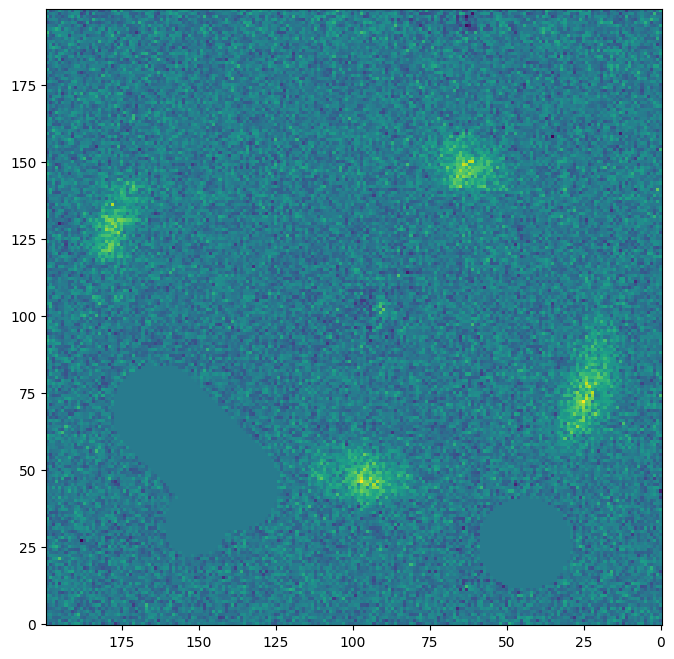

In [7]:
mask_locs = np.array([[45, 60, 15], [47, 58, 15], [49, 56, 15], [51, 54, 15], [53, 52, 15], [55, 50, 15], [57, 48, 15], [59, 46, 15], [61, 44, 15], 
                     [63, 42, 15], [65, 40, 15], [67, 38, 15], [69, 36, 15], [32, 48, 10], [26, 155, 15]]) #, [103, 108, 20]
# mask_locs = np.array([[(j - size//2) + size//2, -(i - size//2) + size//2, s] for i, j, s in mask_locs])

img_mask = np.ones(imset4.datacube_whitelight.shape)
for l in mask_locs:
    img_mask *= mask_circle(l[0], l[1], l[2], img_mask.shape)

imset4.set_mask(img_mask)

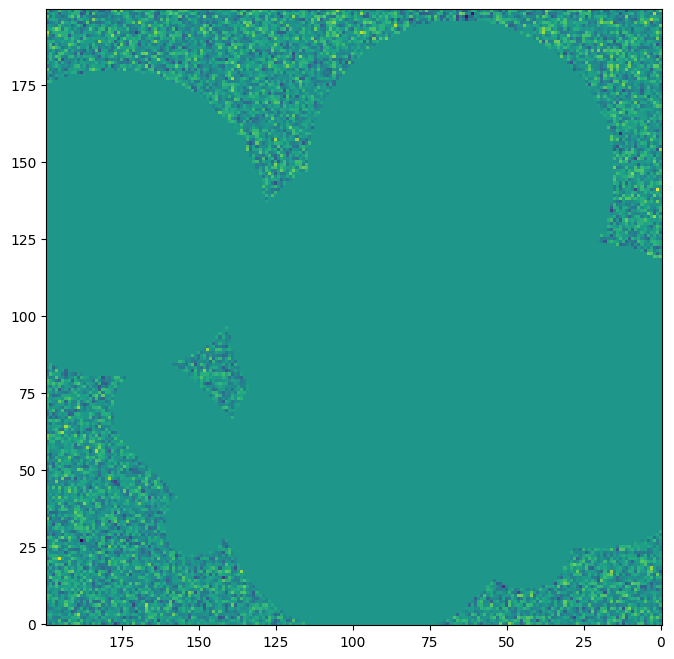

In [8]:
mask_locs = np.array([])

additional_mask = np.ones(imset4.datacube_whitelight.shape)
for l in mask_locs:
    additional_mask *= mask_circle(l[0], l[1], l[2], img_mask.shape)
    
imset4.noise_level_set(50, additional_mask=additional_mask)

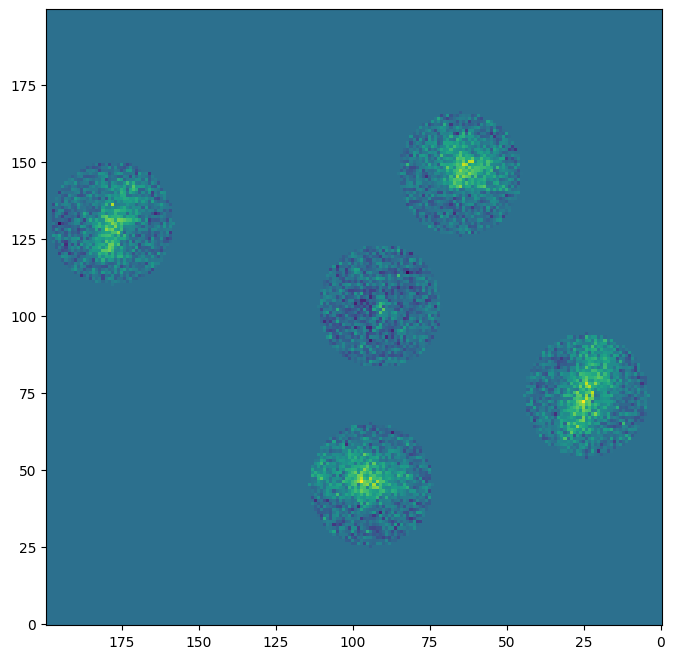

In [9]:
imset4.get_initial_spec_fit_mask(20)

[1.43192055e+00 2.78274019e+00 1.48453687e+04 1.28907884e+00]


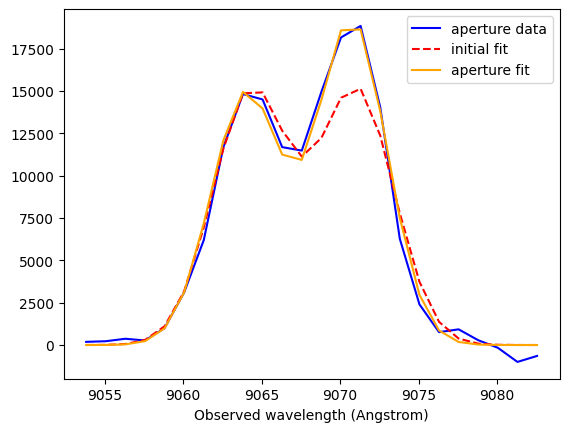

In [10]:
restwave_peaks = [3727.093, 3729.875]
# z, sigma, amp_0, ratios, m, b
init_spec_params = [imset4.zs, 3., 15000., 1.]
imset4.get_initial_spec_fit(restwave_peaks, init_spec_params, rewrite_zs=False, adjust_slope=False)

In [11]:
with open('s4_models/imset4.pickle', 'wb') as handle:
    pickle.dump(imset4, handle, protocol=pickle.HIGHEST_PROTOCOL)